In [1]:
import os
import subprocess
import pandas as pd
import re
import pysam
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#add input files
vcf_files_dir = ("./ARABIENSIS")
ara_vcf_file = f"{vcf_files_dir}/arabiensis_untrimmed.vcf.gz"

output_file2 = f"{vcf_files_dir}/aadongola_merged_filtered_variants.vcf.gz"

In [3]:
#filter the vcf file to have only snps with above 2 alleles
%system bcftools view -m2 {ara_vcf_file} -Oz -o {output_file2}
%system bcftools index {output_file2}


[]

In [4]:
#read the anopheles arabiae vcf file and create a csv file
vcf_file=pysam.VariantFile(output_file2)

def extract_amino_acid_change(annotation):
    match = re.search(r'\b(\d+[A-Z]>\d+[A-Z])\b', annotation)
    if match:
        return match.group(1)
    return None

def extract_gene_name(annotation):
    match = re.search(r'\|([A-Za-z0-9]+)\|', annotation)
    if match:
        return match.group(1)
    return None

def extract_gene_ids(annotation):
    # Search for the gene name pattern within the annotation
    match = re.search(r'\|([A-Za-z0-9_]+)\|', annotation)
    # If a match is found, return the gene name
    if match:
        return match.group(1)
    # Return None if no match is found
    return None
vcf_data = []

for record in vcf_file.fetch():
    vcf_data.append({
        "CHROM": record.chrom,
        "POS": record.pos,
        "ID": record.id,
        "REF": record.ref,
        "ALT": ','.join([str(alt) for alt in record.alts]), 
        "QUAL": record.qual,
        "FILTER": ','.join(record.filter.keys()),
        "ANN": record.info.get('BCSQ', None)
    })

ara_vcf_df = pd.DataFrame(vcf_data)


In [5]:
ara_vcf_df

,CHROM,POS,ID,REF,ALT,QUAL,FILTER,ANN
0,CM029352,3438923,None,A,T,76.000999,PASS,"(intron|AARA21_011240||protein_coding,)"
1,CM029352,3438945,None,C,G,198.802002,PASS,"(intron|AARA21_011240||protein_coding,)"
2,CM029352,3439225,None,C,T,275.002991,PASS,(synonymous|AARA21_011240|AARA21_011240.R21067...
3,CM029352,3439243,None,G,C,275.002991,PASS,(synonymous|AARA21_011240|AARA21_011240.R21067...
4,CM029352,3439252,None,T,C,231.985001,PASS,(synonymous|AARA21_011240|AARA21_011240.R21067...
...,...,...,...,...,...,...,...,...
213,CM029353,28223669,None,C,T,21.389601,PASS,None
214,CM029353,28223680,None,C,T,21.292801,PASS,(missense|AARA21_007478|AARA21_007478.R14028|p...
215,CM029353,28223800,None,C,G,21.077700,PASS,"(intron|AARA21_007478||protein_coding,)"
216,CM029353,28223824,None,C,T,21.404600,PASS,None


In [7]:
#save the dataframe and edit the file(remove all (' and ',) or ') on the ANN column MANUALLY IN AN EXCEL SHEET)
#Additionaly search @ and remove the @ and position i.e @2463572 and any other comma etc 
#example @42810262,’synonymous|ASTEI20_036354|ASTEI20_036354.R45604|protein_coding|-|1473S|42810263C>A remove @42810262,’ to remain with synonymous|ASTEI20_036354|ASTEI20_036354.R45604|protein_co
#@ represents double mutation at a particular aminoacid position i.e L995S and L995F
ara_vcf_df.to_csv("./ARABIENSIS/ara_vcf_raw.csv")
ara_vcf_df.ANN

0                (intron|AARA21_011240||protein_coding,)
1                (intron|AARA21_011240||protein_coding,)
2      (synonymous|AARA21_011240|AARA21_011240.R21067...
3      (synonymous|AARA21_011240|AARA21_011240.R21067...
4      (synonymous|AARA21_011240|AARA21_011240.R21067...
                             ...                        
213                                                 None
214    (missense|AARA21_007478|AARA21_007478.R14028|p...
215              (intron|AARA21_007478||protein_coding,)
216                                                 None
217                                                 None
Name: ANN, Length: 218, dtype: object

In [5]:
#reload the file and filter
ara_vcf_df = pd.read_csv("./ARABIENSIS/ara_vcf_raw.csv")
ara_vcf_df

,Unnamed: 0,CHROM,POS,ID,REF,ALT,QUAL,FILTER,ANN
0,0,CM029352,3438923,NaN,A,T,76.000999,PASS,intron|AARA21_011240||protein_coding
1,1,CM029352,3438945,NaN,C,G,198.802002,PASS,intron|AARA21_011240||protein_coding
2,2,CM029352,3439225,NaN,C,T,275.002991,PASS,synonymous|AARA21_011240|AARA21_011240.R21067|...
3,3,CM029352,3439243,NaN,G,C,275.002991,PASS,synonymous|AARA21_011240|AARA21_011240.R21067|...
4,4,CM029352,3439252,NaN,T,C,231.985001,PASS,synonymous|AARA21_011240|AARA21_011240.R21067|...
...,...,...,...,...,...,...,...,...,...
213,213,CM029353,28223669,NaN,C,T,21.389601,PASS,NaN
214,214,CM029353,28223680,NaN,C,T,21.292801,PASS,missense|AARA21_007478|AARA21_007478.R14028|pr...
215,215,CM029353,28223800,NaN,C,G,21.077700,PASS,intron|AARA21_007478||protein_coding
216,216,CM029353,28223824,NaN,C,T,21.404600,PASS,NaN


In [6]:
# create a dataframe with annotation (geneid,protein change/mutation,location in chromosome/position)- this later helps with plotting
ara_vcf_df['gene_name'] = ara_vcf_df['ANN'].apply(lambda x: extract_gene_ids(str(x)))
ara_vcf_df['Protein_Change'] = ara_vcf_df['ANN'].apply(lambda x: extract_amino_acid_change(str(x)))
ara_vcf_df["LOCATION"]= (ara_vcf_df["CHROM"].astype(str) + ":" + ara_vcf_df["POS"].astype(str) + "-" + ara_vcf_df["gene_name"].astype(str)+ "-" + ara_vcf_df["Protein_Change"].astype(str))
ara_vcf_df

,Unnamed: 0,CHROM,POS,ID,REF,ALT,QUAL,FILTER,ANN,gene_name,Protein_Change,LOCATION
0,0,CM029352,3438923,NaN,A,T,76.000999,PASS,intron|AARA21_011240||protein_coding,AARA21_011240,None,CM029352:3438923-AARA21_011240-None
1,1,CM029352,3438945,NaN,C,G,198.802002,PASS,intron|AARA21_011240||protein_coding,AARA21_011240,None,CM029352:3438945-AARA21_011240-None
2,2,CM029352,3439225,NaN,C,T,275.002991,PASS,synonymous|AARA21_011240|AARA21_011240.R21067|...,AARA21_011240,None,CM029352:3439225-AARA21_011240-None
3,3,CM029352,3439243,NaN,G,C,275.002991,PASS,synonymous|AARA21_011240|AARA21_011240.R21067|...,AARA21_011240,None,CM029352:3439243-AARA21_011240-None
4,4,CM029352,3439252,NaN,T,C,231.985001,PASS,synonymous|AARA21_011240|AARA21_011240.R21067|...,AARA21_011240,None,CM029352:3439252-AARA21_011240-None
...,...,...,...,...,...,...,...,...,...,...,...,...
213,213,CM029353,28223669,NaN,C,T,21.389601,PASS,NaN,None,None,CM029353:28223669-None-None
214,214,CM029353,28223680,NaN,C,T,21.292801,PASS,missense|AARA21_007478|AARA21_007478.R14028|pr...,AARA21_007478,21A>21T,CM029353:28223680-AARA21_007478-21A>21T
215,215,CM029353,28223800,NaN,C,G,21.077700,PASS,intron|AARA21_007478||protein_coding,AARA21_007478,None,CM029353:28223800-AARA21_007478-None
216,216,CM029353,28223824,NaN,C,T,21.404600,PASS,NaN,None,None,CM029353:28223824-None-None


In [7]:
# import sgkit for allele/genotype frequency analysis 
import sgkit as sg
from sgkit.io.vcf import vcf_to_zarr

##load the vcf file
vcf_to_zarr({output_file2},"output.zarr")
ds = sg.load_dataset("output.zarr")
print(ds)


/tmp/ipykernel_8334/4133253917.py:6: DeprecationWarning: Functions for reading VCF are deprecated, please use the bio2zarr package.
  vcf_to_zarr({output_file2},"output.zarr")


<xarray.Dataset> Size: 68kB
Dimensions:               (variants: 218, samples: 45, ploidy: 2, contigs: 102,
                           filters: 4, alleles: 4)
Dimensions without coordinates: variants, samples, ploidy, contigs, filters,
                                alleles
Data variables: (12/14)
    call_genotype         (variants, samples, ploidy) int8 20kB dask.array<chunksize=(218, 45, 2), meta=np.ndarray>
    call_genotype_mask    (variants, samples, ploidy) bool 20kB dask.array<chunksize=(218, 45, 2), meta=np.ndarray>
    call_genotype_phased  (variants, samples) bool 10kB dask.array<chunksize=(218, 45), meta=np.ndarray>
    contig_id             (contigs) <U15 6kB dask.array<chunksize=(102,), meta=np.ndarray>
    contig_length         (contigs) int64 816B dask.array<chunksize=(102,), meta=np.ndarray>
    filter_id             (filters) object 32B dask.array<chunksize=(4,), meta=np.ndarray>
    ...                    ...
    variant_contig        (variants) int8 218B dask.array

In [8]:
df = ~ds.call_genotype_mask.to_dataframe()
call_rates = df.groupby('variants').mean()
call_rates

,call_genotype_mask
variants,
0,0.777778
1,0.977778
2,1.000000
3,1.000000
4,0.977778
...,...
213,0.555556
214,0.555556
215,0.288889


<Axes: title={'center': 'Anopheles arabiensis\nCall Rate Distribution'}, ylabel='Frequency'>

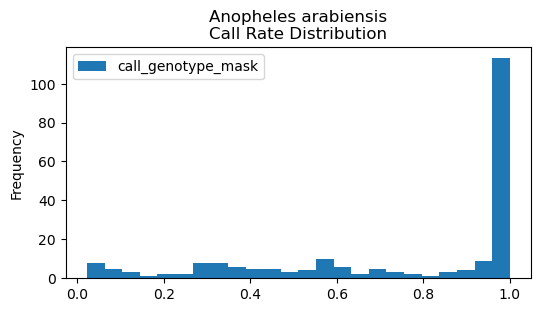

In [9]:
call_rates.plot(kind='hist', bins=24, title='Anopheles arabiensis\nCall Rate Distribution', figsize=(6, 3))

In [10]:
#calculate the variants allele counts and save as an array
ara_allele_count=sg.count_variant_alleles(ds)["variant_allele_count"].values
ara_allele_count

array([[65,  5,  0,  0],
       [78, 10,  0,  0],
       [89,  1,  0,  0],
       [89,  1,  0,  0],
       [71, 17,  0,  0],
       [87,  3,  0,  0],
       [89,  1,  0,  0],
       [71, 19,  0,  0],
       [88,  2,  0,  0],
       [10, 80,  0,  0],
       [31, 57,  0,  0],
       [85,  3,  0,  0],
       [32, 56,  0,  0],
       [16, 74,  0,  0],
       [89,  1,  0,  0],
       [12, 78,  0,  0],
       [70, 14,  0,  0],
       [89,  1,  0,  0],
       [88,  2,  0,  0],
       [88,  2,  0,  0],
       [87,  1,  0,  0],
       [89,  1,  0,  0],
       [89,  1,  0,  0],
       [89,  1,  0,  0],
       [87,  3,  0,  0],
       [48, 34,  0,  0],
       [51, 37,  0,  0],
       [89,  1,  0,  0],
       [88,  2,  0,  0],
       [85,  5,  0,  0],
       [89,  1,  0,  0],
       [89,  1,  0,  0],
       [89,  1,  0,  0],
       [89,  1,  0,  0],
       [86,  4,  0,  0],
       [69, 17,  0,  0],
       [88,  0,  0,  0],
       [78, 12,  0,  0],
       [37, 53,  0,  0],
       [88,  2,  0,  0],


In [11]:
#save the array as a dataframe
allele_count= pd.DataFrame(ara_allele_count)

#change the column names
allele_count.columns=["ref","alt1","alt2","alt3"]

#create a new column with the total count
allele_count["total"]= allele_count.sum(axis=1)

#calculate the frequency for each allele count value
al_frequency_count= allele_count.div(allele_count["total"],axis=0)

#set the position as index, here we add the dataframe created in the first steps for annotation
al_frequency_count.set_index(ara_vcf_df["LOCATION"], inplace=True)

#round off the calculated values to 2decimal place
al_frequency_count=al_frequency_count.round(2)

al_frequency_count


,ref,alt1,alt2,alt3,total
LOCATION,,,,,
CM029352:3438923-AARA21_011240-None,0.93,0.07,0.0,0.0,1.0
CM029352:3438945-AARA21_011240-None,0.89,0.11,0.0,0.0,1.0
CM029352:3439225-AARA21_011240-None,0.99,0.01,0.0,0.0,1.0
CM029352:3439243-AARA21_011240-None,0.99,0.01,0.0,0.0,1.0
CM029352:3439252-AARA21_011240-None,0.81,0.19,0.0,0.0,1.0
...,...,...,...,...,...
CM029353:28223669-None-None,1.00,0.00,0.0,0.0,1.0
CM029353:28223680-AARA21_007478-21A>21T,0.96,0.04,0.0,0.0,1.0
CM029353:28223800-AARA21_007478-None,1.00,0.00,0.0,0.0,1.0


In [12]:
#merge the original vcf dataframe to the allele frequency results
merged_df = pd.merge(ara_vcf_df, al_frequency_count, on=["LOCATION"])

#save the merged file
merged_df.to_csv("./ARABIENSIS/ara_allele_merged.csv")
merged_df

,Unnamed: 0,CHROM,POS,ID,REF,ALT,QUAL,FILTER,ANN,gene_name,Protein_Change,LOCATION,ref,alt1,alt2,alt3,total
0,0,CM029352,3438923,NaN,A,T,76.000999,PASS,intron|AARA21_011240||protein_coding,AARA21_011240,None,CM029352:3438923-AARA21_011240-None,0.93,0.07,0.0,0.0,1.0
1,1,CM029352,3438945,NaN,C,G,198.802002,PASS,intron|AARA21_011240||protein_coding,AARA21_011240,None,CM029352:3438945-AARA21_011240-None,0.89,0.11,0.0,0.0,1.0
2,2,CM029352,3439225,NaN,C,T,275.002991,PASS,synonymous|AARA21_011240|AARA21_011240.R21067|...,AARA21_011240,None,CM029352:3439225-AARA21_011240-None,0.99,0.01,0.0,0.0,1.0
3,3,CM029352,3439243,NaN,G,C,275.002991,PASS,synonymous|AARA21_011240|AARA21_011240.R21067|...,AARA21_011240,None,CM029352:3439243-AARA21_011240-None,0.99,0.01,0.0,0.0,1.0
4,4,CM029352,3439252,NaN,T,C,231.985001,PASS,synonymous|AARA21_011240|AARA21_011240.R21067|...,AARA21_011240,None,CM029352:3439252-AARA21_011240-None,0.81,0.19,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
213,213,CM029353,28223669,NaN,C,T,21.389601,PASS,NaN,None,None,CM029353:28223669-None-None,1.00,0.00,0.0,0.0,1.0
214,214,CM029353,28223680,NaN,C,T,21.292801,PASS,missense|AARA21_007478|AARA21_007478.R14028|pr...,AARA21_007478,21A>21T,CM029353:28223680-AARA21_007478-21A>21T,0.96,0.04,0.0,0.0,1.0
215,215,CM029353,28223800,NaN,C,G,21.077700,PASS,intron|AARA21_007478||protein_coding,AARA21_007478,None,CM029353:28223800-AARA21_007478-None,1.00,0.00,0.0,0.0,1.0
216,216,CM029353,28223824,NaN,C,T,21.404600,PASS,NaN,None,None,CM029353:28223824-None-None,0.93,0.07,0.0,0.0,1.0


In [13]:
#Filter the merged file for plotting.Filtering missense and synonymous mutations to plot the mutation frequencies
missense_df = merged_df[(merged_df['ANN'].str.contains('missense',case=False, na=False)) & (merged_df['alt1'] >= 0.01)] #so we ignore all zeros
plot_missense = missense_df[['ref','alt1']]

synonymous_df = merged_df[(merged_df['ANN'].str.contains('synonymous',case=False, na=False)) & (merged_df['alt1'] >= 0.01)] 
plot_synonymous = synonymous_df[['ref','alt1']]

print(plot_missense)
print(plot_synonymous)


      ref  alt1
46   0.00  1.00
71   0.75  0.25
72   0.87  0.13
73   0.88  0.12
124  0.96  0.04
133  0.00  1.00
134  0.00  1.00
137  0.69  0.31
156  0.73  0.27
172  0.95  0.05
176  0.00  1.00
179  0.67  0.33
185  0.86  0.14
193  0.95  0.05
199  0.65  0.35
214  0.96  0.04
      ref  alt1
2    0.99  0.01
3    0.99  0.01
4    0.81  0.19
5    0.97  0.03
6    0.99  0.01
7    0.79  0.21
15   0.13  0.87
16   0.83  0.17
17   0.99  0.01
18   0.98  0.02
19   0.98  0.02
20   0.99  0.01
21   0.99  0.01
22   0.99  0.01
23   0.99  0.01
24   0.97  0.03
25   0.59  0.41
26   0.58  0.42
27   0.99  0.01
28   0.98  0.02
29   0.94  0.06
30   0.99  0.01
31   0.99  0.01
32   0.99  0.01
33   0.99  0.01
92   0.88  0.12
136  0.15  0.85
138  0.84  0.16
143  0.11  0.89
149  0.96  0.04
155  0.23  0.77
158  0.83  0.17
163  0.12  0.88
178  0.20  0.80
181  0.89  0.11
192  0.92  0.08
198  0.21  0.79
201  0.88  0.12


In [14]:
#set index to the mutations df to help in labeling
plot_missense.set_index(missense_df["LOCATION"], inplace=True)
plot_synonymous.set_index(synonymous_df["LOCATION"], inplace=True)

print(plot_missense)
print(plot_synonymous)

                                              ref  alt1
LOCATION                                               
CM029352:3439986-AARA21_011240-341R>341L     0.00  1.00
CM029352:63292474-AARA21_010834-945F>945Y    0.75  0.25
CM029352:63292642-AARA21_010834-1001L>1001S  0.87  0.13
CM029352:63292643-AARA21_010834-1001L>1001F  0.88  0.12
CM029352:100184036-AARA21_012003-201A>201S   0.96  0.04
CM029353:28213223-AARA21_014232-177Q>177L    0.00  1.00
CM029353:28213226-AARA21_014232-176E>176V    0.00  1.00
CM029353:28213292-AARA21_014232-154S>154T    0.69  0.31
CM029353:28216569-AARA21_014818-154S>154T    0.73  0.27
CM029353:28217132-AARA21_014818-21A>21T      0.95  0.05
CM029353:28219777-AARA21_013962-183E>183V    0.00  1.00
CM029353:28219843-AARA21_013962-161S>161T    0.67  0.33
CM029353:28220048-AARA21_013962-115F>115S    0.86  0.14
CM029353:28220405-AARA21_013962-21A>21T      0.95  0.05
CM029353:28223118-AARA21_007478-161S>161T    0.65  0.35
CM029353:28223680-AARA21_007478-21A>21T      0.9

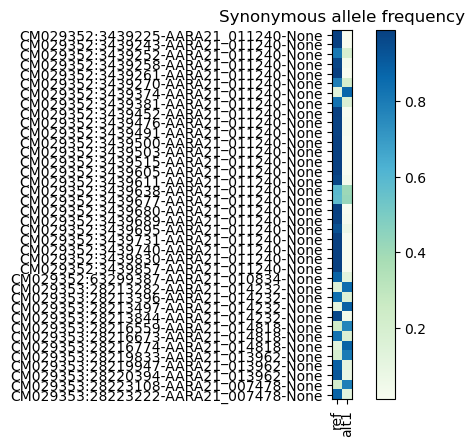

In [15]:
#heatmap plot for the allele counts(synonymous)
plt.imshow(plot_synonymous, cmap='GnBu',vmin=0.01, vmax=0.99)
plt.yticks(ticks=range(len(plot_synonymous.index)), labels=plot_synonymous.index)
plt.xticks(ticks=range(len(plot_synonymous.columns)), labels=plot_synonymous.columns,rotation=90)
plt.title('Synonymous allele frequency')
plt.colorbar()
plt.show()


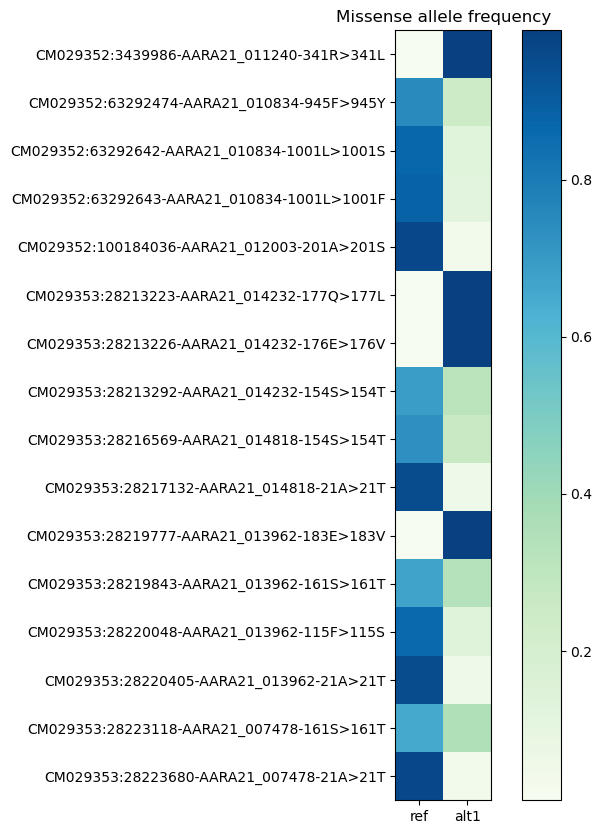

In [16]:
#heatmap plot for the allele frequency(missense)
plt.figure(figsize=(8, 10))
plt.imshow(plot_missense, cmap='GnBu',vmin=0.01, vmax=0.99)
plt.yticks(ticks=range(len(plot_missense.index)), labels=plot_missense.index)
plt.xticks(ticks=range(len(plot_missense.columns)), labels=plot_missense.columns)
plt.title('Missense allele frequency')
plt.colorbar()
plt.show()


In [17]:
#summary variant counts per target
rdl=missense_df[
    (missense_df['ANN'].str.contains('AARA21_012003', case=False, na=False)) 
]
gste2=missense_df[
    (missense_df['ANN'].str.contains('AARA21_013962', case=False, na=False)) 
]
ace=missense_df[
    (missense_df['ANN'].str.contains('AARA21_011240', case=False, na=False)) 
]
para=missense_df[
    (missense_df['ANN'].str.contains('AARA21_010834', case=False, na=False)) 
]

rdl.count()
#para.count()
#ace.count()
#gste2.count()


Unnamed: 0        1
CHROM             1
POS               1
ID                0
REF               1
ALT               1
QUAL              1
FILTER            1
ANN               1
gene_name         1
Protein_Change    1
LOCATION          1
ref               1
alt1              1
alt2              1
alt3              1
total             1
dtype: int64

In [40]:
rdl=synonymous_df[
    (synonymous_df['ANN'].str.contains('AARA21_012003', case=False, na=False)) 
]
gste2=synonymous_df[
    (synonymous_df['ANN'].str.contains('AARA21_013962', case=False, na=False)) 
]
ace=synonymous_df[
    (synonymous_df['ANN'].str.contains('AARA21_011240', case=False, na=False)) 
]
para=synonymous_df[
    (synonymous_df['ANN'].str.contains('AARA21_010834', case=False, na=False)) 
]

##rdl.count()
#para.count()
#ace.count()
gste2.count()

Unnamed: 0        3
CHROM             3
POS               3
ID                0
REF               3
ALT               3
QUAL              3
FILTER            3
ANN               3
gene_name         3
Protein_Change    0
LOCATION          3
ref               3
alt1              3
alt2              3
alt3              3
total             3
dtype: int64

In [41]:
#calculate the variants genotype count
genotype_count=sg.count_variant_genotypes(ds)["variant_genotype_count"].values

#change it to a dataframe and calculate the total for each variant
genotype_count= pd.DataFrame(genotype_count)
genotype_count["total"]= genotype_count.sum(axis=1)

#calculate the genotype frequencies
genotype_frequency_count= genotype_count.div(genotype_count["total"],axis=0)

#set the position as index 
genotype_frequency_count.set_index(ara_vcf_df["LOCATION"], inplace=True)
genotype_frequency_count

ValueError: destination buffer too small; expected at least 38226, got 19620

In [20]:
#this help us know the corresponding column names so that i can use them to re-lable using the coordinates(genotypes)
sg.count_variant_genotypes(ds)["variant_genotype_count"]

<xarray.DataArray 'variant_genotype_count' (variants: 218, genotypes: 10)> Size: 17kB
dask.array<_count_sorted_genotypes, shape=(218, 10), dtype=uint64, chunksize=(218, 10), chunktype=numpy.ndarray>
Coordinates:
  * genotypes  (genotypes) <U3 120B '0/0' '0/1' '1/1' ... '1/3' '2/3' '3/3'
Dimensions without coordinates: variants
Attributes:
    comment:  The number of observations for each possible genotype at each v...

In [21]:
#change the column name to this
genotype_frequency_count.columns=['GT:0/0', 'GT:0/1', 'GT:1/1', 'GT:0/2', 'GT:1/2', 'GT:2/2', 'GT:0/3','GT:1/3','GT:2/3', 'GT:3/3','total']

In [22]:
#round off the calculated values to 2decimal place
genotype_frequency_count=genotype_frequency_count.round(2)
genotype_frequency_count

,GT:0/0,GT:0/1,GT:1/1,GT:0/2,GT:1/2,GT:2/2,GT:0/3,GT:1/3,GT:2/3,GT:3/3,total
LOCATION,,,,,,,,,,,
CM029352:3438923-AARA21_011240-None,0.86,0.14,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
CM029352:3438945-AARA21_011240-None,0.77,0.23,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
CM029352:3439225-AARA21_011240-None,0.98,0.02,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
CM029352:3439243-AARA21_011240-None,0.98,0.02,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
CM029352:3439252-AARA21_011240-None,0.64,0.34,0.02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
CM029353:28223669-None-None,1.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
CM029353:28223680-AARA21_007478-21A>21T,0.96,0.00,0.04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
CM029353:28223800-AARA21_007478-None,1.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [23]:
#merge the original vcf dataframe to the genotype frequency results
genotype_merged_df = pd.merge(ara_vcf_df, genotype_frequency_count, on=["LOCATION"])

#save the merged file

genotype_merged_df.to_csv("./ARABIENSIS/ara_genotype_merged.csv")
genotype_merged_df

,Unnamed: 0,CHROM,POS,ID,REF,ALT,QUAL,FILTER,ANN,gene_name,...,GT:0/1,GT:1/1,GT:0/2,GT:1/2,GT:2/2,GT:0/3,GT:1/3,GT:2/3,GT:3/3,total
0,0,CM029352,3438923,NaN,A,T,76.000999,PASS,intron|AARA21_011240||protein_coding,AARA21_011240,...,0.14,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,1,CM029352,3438945,NaN,C,G,198.802002,PASS,intron|AARA21_011240||protein_coding,AARA21_011240,...,0.23,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,2,CM029352,3439225,NaN,C,T,275.002991,PASS,synonymous|AARA21_011240|AARA21_011240.R21067|...,AARA21_011240,...,0.02,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,3,CM029352,3439243,NaN,G,C,275.002991,PASS,synonymous|AARA21_011240|AARA21_011240.R21067|...,AARA21_011240,...,0.02,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,4,CM029352,3439252,NaN,T,C,231.985001,PASS,synonymous|AARA21_011240|AARA21_011240.R21067|...,AARA21_011240,...,0.34,0.02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
213,213,CM029353,28223669,NaN,C,T,21.389601,PASS,NaN,None,...,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
214,214,CM029353,28223680,NaN,C,T,21.292801,PASS,missense|AARA21_007478|AARA21_007478.R14028|pr...,AARA21_007478,...,0.00,0.04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
215,215,CM029353,28223800,NaN,C,G,21.077700,PASS,intron|AARA21_007478||protein_coding,AARA21_007478,...,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
216,216,CM029353,28223824,NaN,C,T,21.404600,PASS,NaN,None,...,0.00,0.07,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [24]:
#Filter the merged file for plotting.Filtering missense and synonymous mutations to plot the mutation frequencies
genotype_missense_df = genotype_merged_df[(genotype_merged_df['ANN'].str.contains('missense',case=False, na=False)) & (genotype_merged_df['GT:0/1'] >= 0.01)] #so we ignore all zeros
plotgt_missense = genotype_missense_df[['GT:0/0','GT:0/1','GT:1/1']]

genotype_synonymous_df = genotype_merged_df[(genotype_merged_df['ANN'].str.contains('synonymous',case=False, na=False)) & (genotype_merged_df['GT:0/1'] >= 0.01)] 
plotgt_synonymous = genotype_synonymous_df[['GT:0/0','GT:0/1','GT:1/1']]

print(plotgt_missense)
print(plotgt_synonymous)

     GT:0/0  GT:0/1  GT:1/1
71     0.50    0.50    0.00
72     0.76    0.22    0.02
73     0.76    0.24    0.00
124    0.91    0.09    0.00
    GT:0/0  GT:0/1  GT:1/1
2     0.98    0.02    0.00
3     0.98    0.02    0.00
4     0.64    0.34    0.02
5     0.93    0.07    0.00
6     0.98    0.02    0.00
7     0.60    0.38    0.02
15    0.02    0.22    0.76
16    0.69    0.29    0.02
17    0.98    0.02    0.00
18    0.96    0.04    0.00
19    0.96    0.04    0.00
20    0.98    0.02    0.00
21    0.98    0.02    0.00
22    0.98    0.02    0.00
23    0.98    0.02    0.00
24    0.93    0.07    0.00
25    0.32    0.54    0.15
26    0.32    0.52    0.16
27    0.98    0.02    0.00
28    0.96    0.04    0.00
29    0.91    0.07    0.02
30    0.98    0.02    0.00
31    0.98    0.02    0.00
32    0.98    0.02    0.00
33    0.98    0.02    0.00
92    0.77    0.20    0.02


In [25]:
#set index to the mutations df to help in labelling
plotgt_missense.set_index(genotype_missense_df["LOCATION"], inplace=True)
plotgt_synonymous.set_index(genotype_synonymous_df["LOCATION"], inplace=True)

print(plotgt_missense)
plotgt_synonymous

                                             GT:0/0  GT:0/1  GT:1/1
LOCATION                                                           
CM029352:63292474-AARA21_010834-945F>945Y      0.50    0.50    0.00
CM029352:63292642-AARA21_010834-1001L>1001S    0.76    0.22    0.02
CM029352:63292643-AARA21_010834-1001L>1001F    0.76    0.24    0.00
CM029352:100184036-AARA21_012003-201A>201S     0.91    0.09    0.00


,GT:0/0,GT:0/1,GT:1/1
LOCATION,,,
CM029352:3439225-AARA21_011240-None,0.98,0.02,0.00
CM029352:3439243-AARA21_011240-None,0.98,0.02,0.00
CM029352:3439252-AARA21_011240-None,0.64,0.34,0.02
CM029352:3439258-AARA21_011240-None,0.93,0.07,0.00
CM029352:3439261-AARA21_011240-None,0.98,0.02,0.00
CM029352:3439270-AARA21_011240-None,0.60,0.38,0.02
CM029352:3439374-AARA21_011240-None,0.02,0.22,0.76
CM029352:3439381-AARA21_011240-None,0.69,0.29,0.02
CM029352:3439452-AARA21_011240-None,0.98,0.02,0.00


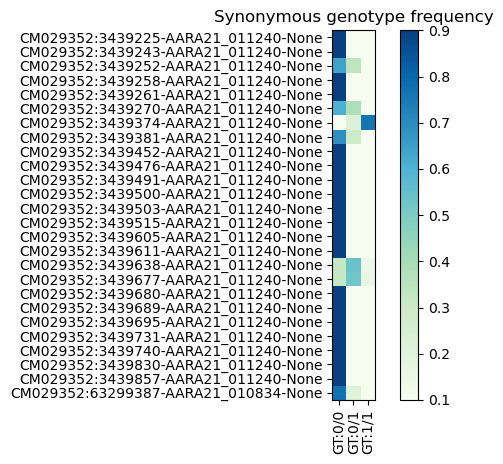

In [26]:
#heatmap plot for the allele counts(synonymous)
plt.imshow(plotgt_synonymous, cmap='GnBu',vmin=0.1, vmax=0.9)
plt.yticks(ticks=range(len(plotgt_synonymous.index)), labels=plotgt_synonymous.index,)
plt.xticks(ticks=range(len(plotgt_synonymous.columns)), labels=plotgt_synonymous.columns, rotation=90)
plt.title('Synonymous genotype frequency')
plt.colorbar()
plt.show()


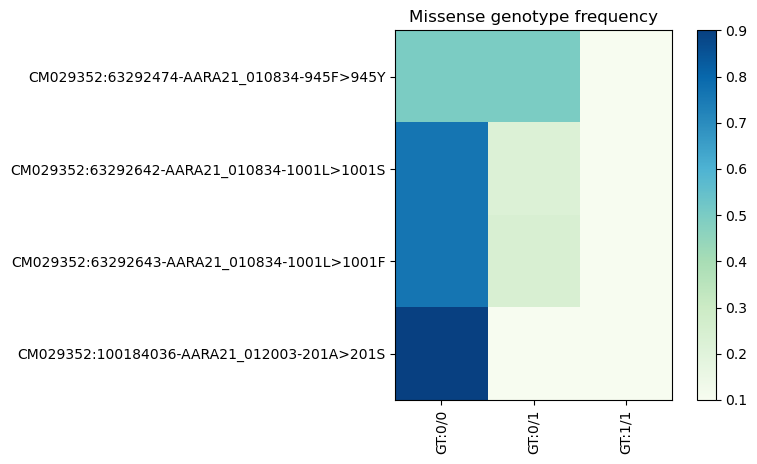

In [27]:
#heatmap plot for the allele counts(missense)
plt.imshow(plotgt_missense, cmap='GnBu',vmin=0.1, vmax=0.9)
plt.yticks(ticks=range(len(plotgt_missense.index)), labels=plotgt_missense.index)
plt.xticks(ticks=range(len(plotgt_missense.columns)), labels=plotgt_missense.columns, rotation=90)
plt.title('Missense genotype frequency')
plt.colorbar()
plt.show()


In [28]:
#merge the final dataframe
aa_al_gt_merged_df = pd.merge(genotype_merged_df, al_frequency_count, on=["LOCATION"])
aa_al_gt_merged_df.to_csv("./ARABIENSIS/aa_al_gt_merged.csv")
aa_al_gt_merged_df

,Unnamed: 0,CHROM,POS,ID,REF,ALT,QUAL,FILTER,ANN,gene_name,...,GT:0/3,GT:1/3,GT:2/3,GT:3/3,total_x,ref,alt1,alt2,alt3,total_y
0,0,CM029352,3438923,NaN,A,T,76.000999,PASS,intron|AARA21_011240||protein_coding,AARA21_011240,...,0.0,0.0,0.0,0.0,1.0,0.93,0.07,0.0,0.0,1.0
1,1,CM029352,3438945,NaN,C,G,198.802002,PASS,intron|AARA21_011240||protein_coding,AARA21_011240,...,0.0,0.0,0.0,0.0,1.0,0.89,0.11,0.0,0.0,1.0
2,2,CM029352,3439225,NaN,C,T,275.002991,PASS,synonymous|AARA21_011240|AARA21_011240.R21067|...,AARA21_011240,...,0.0,0.0,0.0,0.0,1.0,0.99,0.01,0.0,0.0,1.0
3,3,CM029352,3439243,NaN,G,C,275.002991,PASS,synonymous|AARA21_011240|AARA21_011240.R21067|...,AARA21_011240,...,0.0,0.0,0.0,0.0,1.0,0.99,0.01,0.0,0.0,1.0
4,4,CM029352,3439252,NaN,T,C,231.985001,PASS,synonymous|AARA21_011240|AARA21_011240.R21067|...,AARA21_011240,...,0.0,0.0,0.0,0.0,1.0,0.81,0.19,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
213,213,CM029353,28223669,NaN,C,T,21.389601,PASS,NaN,None,...,0.0,0.0,0.0,0.0,1.0,1.00,0.00,0.0,0.0,1.0
214,214,CM029353,28223680,NaN,C,T,21.292801,PASS,missense|AARA21_007478|AARA21_007478.R14028|pr...,AARA21_007478,...,0.0,0.0,0.0,0.0,1.0,0.96,0.04,0.0,0.0,1.0
215,215,CM029353,28223800,NaN,C,G,21.077700,PASS,intron|AARA21_007478||protein_coding,AARA21_007478,...,0.0,0.0,0.0,0.0,1.0,1.00,0.00,0.0,0.0,1.0
216,216,CM029353,28223824,NaN,C,T,21.404600,PASS,NaN,None,...,0.0,0.0,0.0,0.0,1.0,0.93,0.07,0.0,0.0,1.0


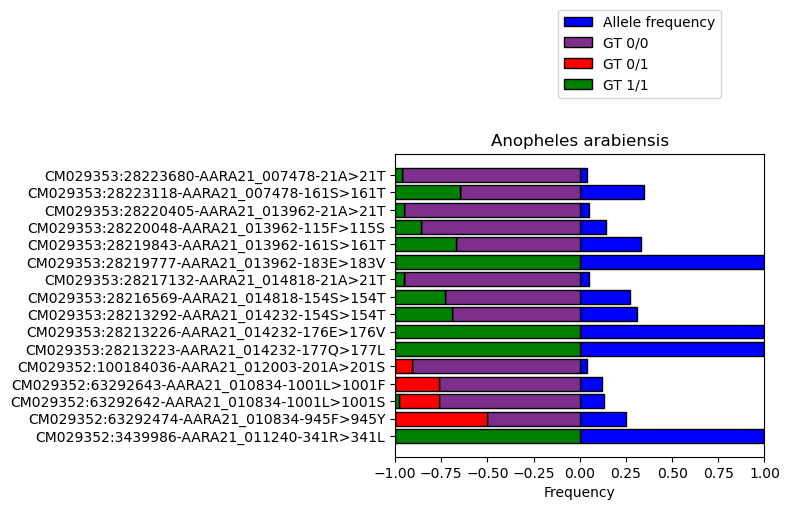

In [30]:
import matplotlib.pyplot as plt
import numpy as np

# SNPS data
positions = np.array(merged_all_df["LOCATION"])
aa_change = np.array(merged_all_df["alt1"])

# Genotype data
snps_gt_00 = -np.array(merged_all_df["GT:0/0"])  # GT 0/0
snps_gt_01 = -np.array(merged_all_df["GT:0/1"])  # GT 0/1
snps_gt_11 = -np.array(merged_all_df["GT:1/1"])  # GT 1/1

# Plotting
fig, ax = plt.subplots(figsize=(8, 6))

# Plot the allele frequency
ax.barh(positions, aa_change, color='blue', edgecolor='black', label='Allele frequency')

# Plot stacked genotype frequencies
bottom = np.zeros(len(positions))
ax.barh(positions, snps_gt_00, left=bottom, color="#7E2F8E", edgecolor='black', label='GT 0/0')
bottom += snps_gt_00
ax.barh(positions, snps_gt_01, left=bottom, color='red', edgecolor='black', label='GT 0/1')
bottom += snps_gt_01
ax.barh(positions, snps_gt_11, left=bottom, color='green', edgecolor='black', label='GT 1/1')



# Adding labels and title
ax.set_xlabel('Frequency')
#ax.set_xlim(-10, 10)
ax.set_title('Anopheles arabiensis')
ax.legend(loc='upper right',bbox_to_anchor=(0.9, 1.5))
ax.set_xlim(-1, 1)
# Display the plot
plt.tight_layout()
plt.show()

In [31]:
#create a new column with gene symbol
#merged_all_df
#dictionary
gene_mapping = {
    'AARA21_011240': 'Ace2',
    'AARA21_010834': 'Vgsc',
    'AARA21_012003': 'Gaba',
    'AARA21_014232': 'Gste2_1',
    'AARA21_014818': 'Gste3',
    'AARA21_013962': 'Gste2_2',
    'AARA21_007478': 'Gste2_3',
}

# Create new column with mapped values
merged_all_df['Gene_symbol'] = merged_all_df['gene_name'].map(gene_mapping).fillna(merged_all_df['gene_name'])
merged_all_df.Gene_symbol

#create new column with final plot label
merged_all_df["Label"]= (merged_all_df["Gene_symbol"].astype(str) + "(" + merged_all_df["Protein_Change"].astype(str) + ")")
merged_all_df.Label


/tmp/ipykernel_8334/240695952.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_all_df['Gene_symbol'] = merged_all_df['gene_name'].map(gene_mapping).fillna(merged_all_df['gene_name'])
/tmp/ipykernel_8334/240695952.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_all_df["Label"]= (merged_all_df["Gene_symbol"].astype(str) + "(" + merged_all_df["Protein_Change"].astype(str) + ")")


46        Ace2(341R>341L)
71        Vgsc(945F>945Y)
72      Vgsc(1001L>1001S)
73      Vgsc(1001L>1001F)
124       Gaba(201A>201S)
133    Gste2_1(177Q>177L)
134    Gste2_1(176E>176V)
137    Gste2_1(154S>154T)
156      Gste3(154S>154T)
172        Gste3(21A>21T)
176    Gste2_2(183E>183V)
179    Gste2_2(161S>161T)
185    Gste2_2(115F>115S)
193      Gste2_2(21A>21T)
199    Gste2_3(161S>161T)
214      Gste2_3(21A>21T)
Name: Label, dtype: object

In [32]:
#change the aminoacid position to known gambiae position RD
#for kdr east/west VGSC region
merged_all_df.at[72, 'Label'] = 'Vgsc(995L>995S)'
merged_all_df.at[72, 'Label'] 

merged_all_df.at[73, 'Label'] = 'Vgsc(995L>995F)'
merged_all_df.at[73, 'Label'] 


merged_all_df.at[71, 'Label'] = 'Vgsc(939F>939Y)'
merged_all_df.at[71, 'Label'] 

merged_all_df.at[124, 'Label'] = 'Gaba(296A>296S)'
merged_all_df.at[124, 'Label'] 

merged_all_df.to_csv("./ARABIENSIS/arabiensis_merged.csv")

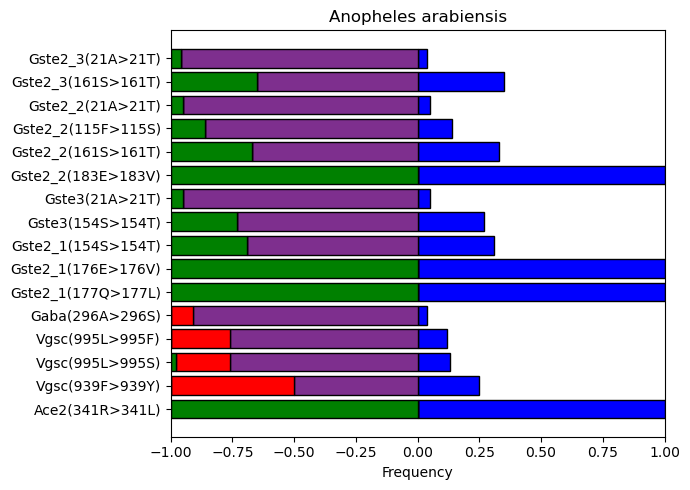

In [33]:
import matplotlib.pyplot as plt
import numpy as np

# SNPS data
positions = np.array(merged_all_df["Label"])
aa_change = np.array(merged_all_df["alt1"])

# Genotype data
snps_gt_00 = -np.array(merged_all_df["GT:0/0"])  # GT 0/0
snps_gt_01 = -np.array(merged_all_df["GT:0/1"])  # GT 0/1
snps_gt_11 = -np.array(merged_all_df["GT:1/1"])  # GT 1/1

# Plotting
fig, ax = plt.subplots(figsize=(7, 5))

# Plot the allele frequency
ax.barh(positions, aa_change, color='blue', edgecolor='black', label='Allele frequency')

# Plot stacked genotype frequencies
bottom = np.zeros(len(positions))
ax.barh(positions, snps_gt_00, left=bottom, color="#7E2F8E", edgecolor='black', label='GT 0/0')
bottom += snps_gt_00
ax.barh(positions, snps_gt_01, left=bottom, color='red', edgecolor='black', label='GT 0/1')
bottom += snps_gt_01
ax.barh(positions, snps_gt_11, left=bottom, color='green', edgecolor='black', label='GT 1/1')


# Adding labels and title
ax.set_xlabel('Frequency')
#ax.set_xlim(-10, 10)
ax.set_title('Anopheles arabiensis')
#ax.legend(loc='upper right',bbox_to_anchor=(0.9, 1.3))
ax.set_xlim(-1, 1)
# Display the plot
plt.tight_layout()
plt.show()